1. Using diamonds.csv dataset  
a. Describe all columns and find mean, median and mode of ‘price’ column  
b. Plot boxplot of column ‘depth’ and find quartiles, median, upper and lower limit  
c. Compare Trimmed mean and mean of ‘carat’ column, what do you infer from it  
d. Plot heatmap of all columns and list features having high correlation (above 0.7)    
e. Plot a Bubble chart with ‘x’, ‘y’ and ‘z’ as features  

In [28]:
import pandas as pd

df = pd.read_csv('diamonds.csv')

print(df.head())

   Unnamed: 0  carat      cut color clarity  depth  table  price     x     y  \
0           1   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98   
1           2   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84   
2           3   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07   
3           4   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23   
4           5   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35   

      z  
0  2.43  
1  2.31  
2  2.31  
3  2.63  
4  2.75  


In [29]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [30]:
mean_of_price = df['price'].mean()
print(mean_of_price)

3932.799721913237


In [31]:
df['price'].median()

2401.0

In [32]:
print(df['price'].mode())

0    605
Name: price, dtype: int64


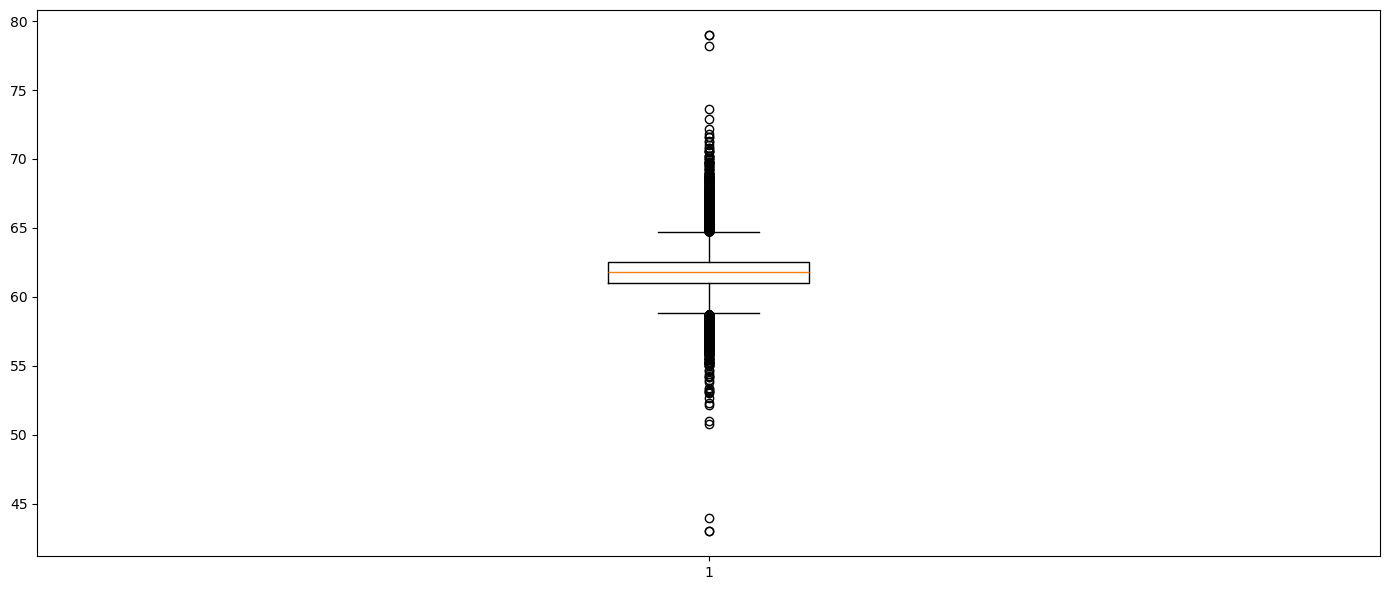

Q1 (25th percentile): 61.0
Q3 (75th percentile): 62.5
Median: 61.8
IQR: 1.5
Lower Limit: 58.75
Upper Limit: 64.75


In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.boxplot(df['depth'])
plt.tight_layout()
plt.show()

# Calculate quartiles, median, and limits
Q1 = df['depth'].quantile(0.25)
Q3 = df['depth'].quantile(0.75)
median = df['depth'].median()
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"Median: {median}")
print(f"IQR: {IQR}")
print(f"Lower Limit: {lower_limit}")
print(f"Upper Limit: {upper_limit}")

In [34]:
from scipy import stats

trimmed_mean = stats.trim_mean(df['carat'], 0.1)
print("\nTrimmed Mean: ",trimmed_mean)
print("\nMean: ", df['carat'].mean())

# Inference: if trimmed mean << mean, outliers are inflating the mean


Trimmed Mean:  0.7349654708935854

Mean:  0.7979397478680014


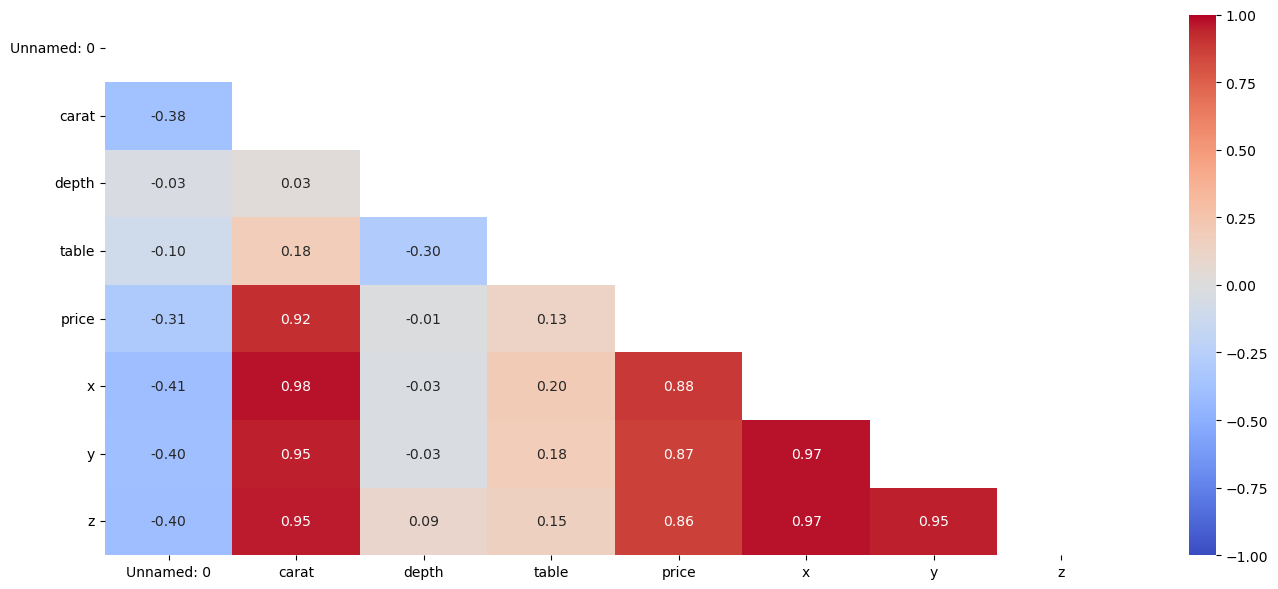

High correlation pairs (abs > 0.7):
carat and price: 0.92
carat and x: 0.98
carat and y: 0.95
carat and z: 0.95
price and x: 0.88
price and y: 0.87
price and z: 0.86
x and y: 0.97
x and z: 0.97
y and z: 0.95

Features with high correlation (>0.7): ['carat', 'price', 'x', 'y', 'z']


In [35]:
import numpy as np
import seaborn as sns
from itertools import combinations

# use only numeric columns for correlation
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()

# heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(14,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', mask=mask, vmin=-1, vmax=1)
plt.tight_layout()
plt.show()

# list high-correlation feature pairs (abs > 0.7)
high_pairs = [(a, b, corr.loc[a, b]) for a, b in combinations(corr.columns, 2) if abs(corr.loc[a, b]) > 0.7]
print("High correlation pairs (abs > 0.7):")
for a, b, v in high_pairs:
    print(f"{a} and {b}: {v:.2f}")

# unique features involved in high correlations
high_features = sorted({f for pair in high_pairs for f in pair[:2]})
print("\nFeatures with high correlation (>0.7):", high_features)

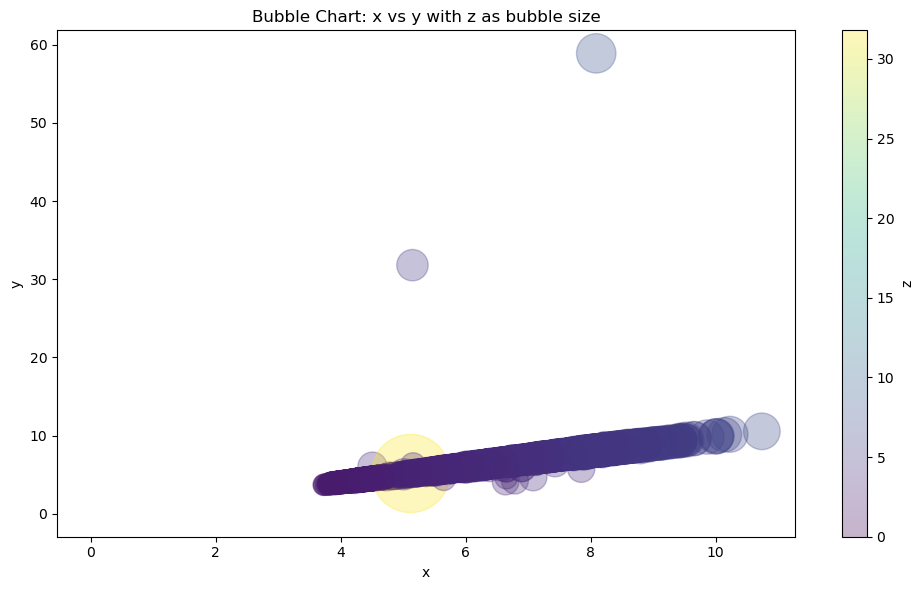

In [36]:
plt.figure(figsize=(10, 6))
plt.scatter(df['x'], df['y'], s=df['z'] * 100, alpha=0.3, c=df['z'], cmap='viridis')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Bubble Chart: x vs y with z as bubble size')
plt.colorbar(label='z')
plt.tight_layout()
plt.show()